# OpenClassrooms - parcours Data Analyst Business Intelligence - P8

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

## 1.Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent (exemple : nettoyage ou changement de type des variables, etc.).

In [2]:
#On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd, numpy as np
# N'oubliez pas d'avoir installé les librairies pandas, numpy et matplotlib via la commande pip
import matplotlib.pyplot as plt

In [3]:
#On importe les données dans un dataframe
sales = pd.read_excel("historique_immobilier_paris_2017_2021.xlsx")
portfolio = pd.read_excel("portefeuille_actifs.xlsx")

In [4]:
#On vérifie que le type des données attribué par pandas est cohérent
sales["date_mutation"] = pd.to_datetime(sales["date_mutation"])
sales["code_postal"] = sales["code_postal"].astype(str)
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26196 entries, 0 to 26195
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26196 non-null  datetime64[ns]
 1   valeur_fonciere   26196 non-null  float64       
 2   adresse_numero    26196 non-null  int64         
 3   adresse_nom_voie  26196 non-null  object        
 4   code_postal       26196 non-null  object        
 5   nom_commune       26196 non-null  object        
 6   code_type_local   26196 non-null  int64         
 7   type_local        26196 non-null  object        
 8   surface_reelle    26196 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 1.8+ MB


### 2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [5]:
print('La liste des différents types de biens immobiliers que nous avons dans les données est : ' + str(sorted(portfolio["type_local"].dropna().unique())))

La liste des différents types de biens immobiliers que nous avons dans les données est : ['Appartement', 'Local industriel. commercial ou assimilé']


On observe qu'il y a 2 types de biens, et que leurs codes types sont 2 et 4.

### 3. Nombre de transactions

In [6]:
#On verifie le nombre de transactions que nous avons dans notre dataframe
print('Le nombre de transactions dans les données est : ' + str(len(sales)))
print('Le nombre de transactions pour les appartements dans les données est : ' + str(sales[sales["type_local"] == "Appartement"].shape[0]))
print('Le nombre de transactions pour les locaux commerciaux dans les données est : ' + str(sales[sales["type_local"] == "Local industriel. commercial ou assimilé"].shape[0]))
print('La part de transactions pour les appartements dans les données est : ' + str(round(sales[sales["type_local"] == "Appartement"].shape[0]/len(sales)*100,1)) + "%")

Le nombre de transactions dans les données est : 26196
Le nombre de transactions pour les appartements dans les données est : 24353
Le nombre de transactions pour les locaux commerciaux dans les données est : 1843
La part de transactions pour les appartements dans les données est : 93.0%


### 4. Intervalle de l'historique des données

In [7]:
#On vérifie également la plage de l'historique disponible
print('la première date de transaction dans les données est le : ' + str(min(sales["date_mutation"])))
print('la dernière date de transaction dans les données est le : ' + str(max(sales["date_mutation"])))

la première date de transaction dans les données est le : 2017-01-02 00:00:00
la dernière date de transaction dans les données est le : 2021-12-31 00:00:00


## Commençons à analyser les données

Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [8]:
# Calcul de la colonne
sales["prix_m2"] = sales["valeur_fonciere"]/sales["surface_reelle"] #, errors="coerce")

Maintenant, analysons les appartements.

### 5. Evolution du prix au metre carré des appartements dans Paris

In [9]:
#On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps
sales_flats_price = sales[sales["type_local"] == "Appartement"][["date_mutation", "prix_m2"]].copy()

In [10]:
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée
sales_flats_price["annee"] = sales_flats_price["date_mutation"].dt.year

evolution_prix = (
    sales_flats_price
    .groupby("annee")["prix_m2"]
    .mean()
    .round()
    .reset_index()
)

evolution_prix

,annee,prix_m2
0,2017,9493.0
1,2018,10031.0
2,2019,10563.0
3,2020,10675.0
4,2021,10456.0


On constate sur la moyenne des prix de vente des appartements à Paris que les prix montent de 2017 à 2020 avant un repli en 2021.
Nous allons créer un graphique pour mieux le visualiser.

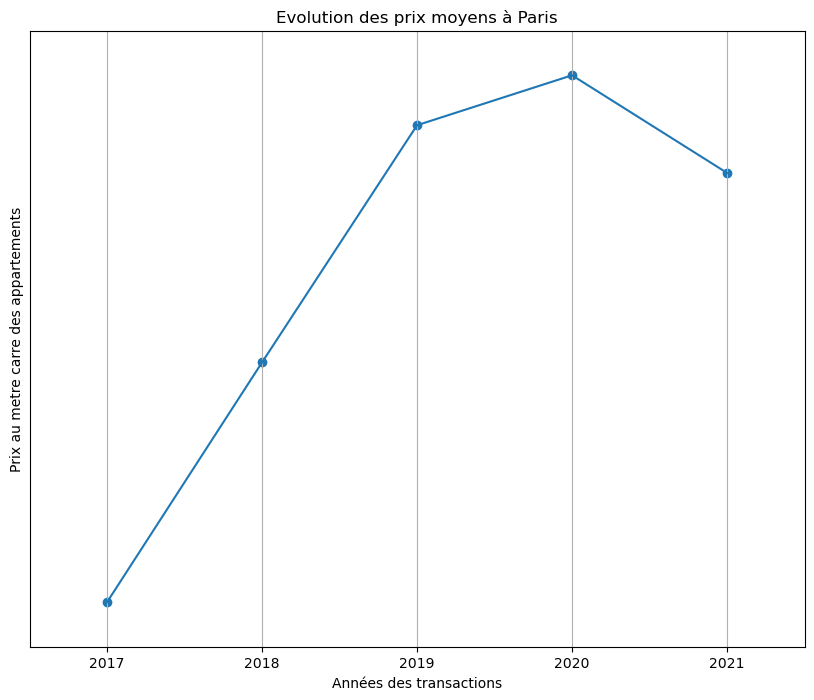

In [11]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.figure(figsize=(10,8))
plt.scatter(evolution_prix["annee"], evolution_prix["prix_m2"])
plt.plot(evolution_prix["annee"], evolution_prix["prix_m2"])
plt.plot(['2017','2018','2019','2020','2021'])
plt.xlabel('Années des transactions')
plt.ylabel('Prix au metre carre des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.xlim(evolution_prix["annee"].min()-0.5,
         evolution_prix["annee"].max()+0.5)
plt.ylim(evolution_prix["prix_m2"].min()-100,
         evolution_prix["prix_m2"].max()+100)
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution des prix moyens à Paris')
plt.show()

### 6. Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [12]:
#Liste des codes postaux dans nos données.
print('La liste des différents codes postaux dans les données est : ' + str(sorted(sales["code_postal"].dropna().unique())))

La liste des différents codes postaux dans les données est : ['75001', '75002', '75003', '75004', '75005', '75006', '75007', '75008', '75009', '75010', '75011', '75012', '75013', '75014', '75015', '75016', '75017', '75018', '75019', '75020']


In [13]:
#Créons un dataframe pour une deuxième visualisation avec l'evolution des prix par arrondissement
sales_flats_price_arrond = sales[sales["type_local"] == "Appartement"][["date_mutation", "code_postal", "prix_m2"]].copy()
sales_flats_price_arrond["annee"] = sales_flats_price_arrond["date_mutation"].dt.year

evolution_prix_arrond = (
    sales_flats_price_arrond
    .groupby(["annee", "code_postal"])["prix_m2"]
    .mean()
    .round()
    .reset_index()
)

evolution_prix_arrond

,annee,code_postal,prix_m2
0,2017,75001,11763.0
1,2017,75002,10920.0
2,2017,75003,11680.0
3,2017,75004,12407.0
4,2017,75005,11307.0
...,...,...,...
95,2021,75016,10790.0
96,2021,75017,10372.0
97,2021,75018,9666.0
98,2021,75019,8829.0


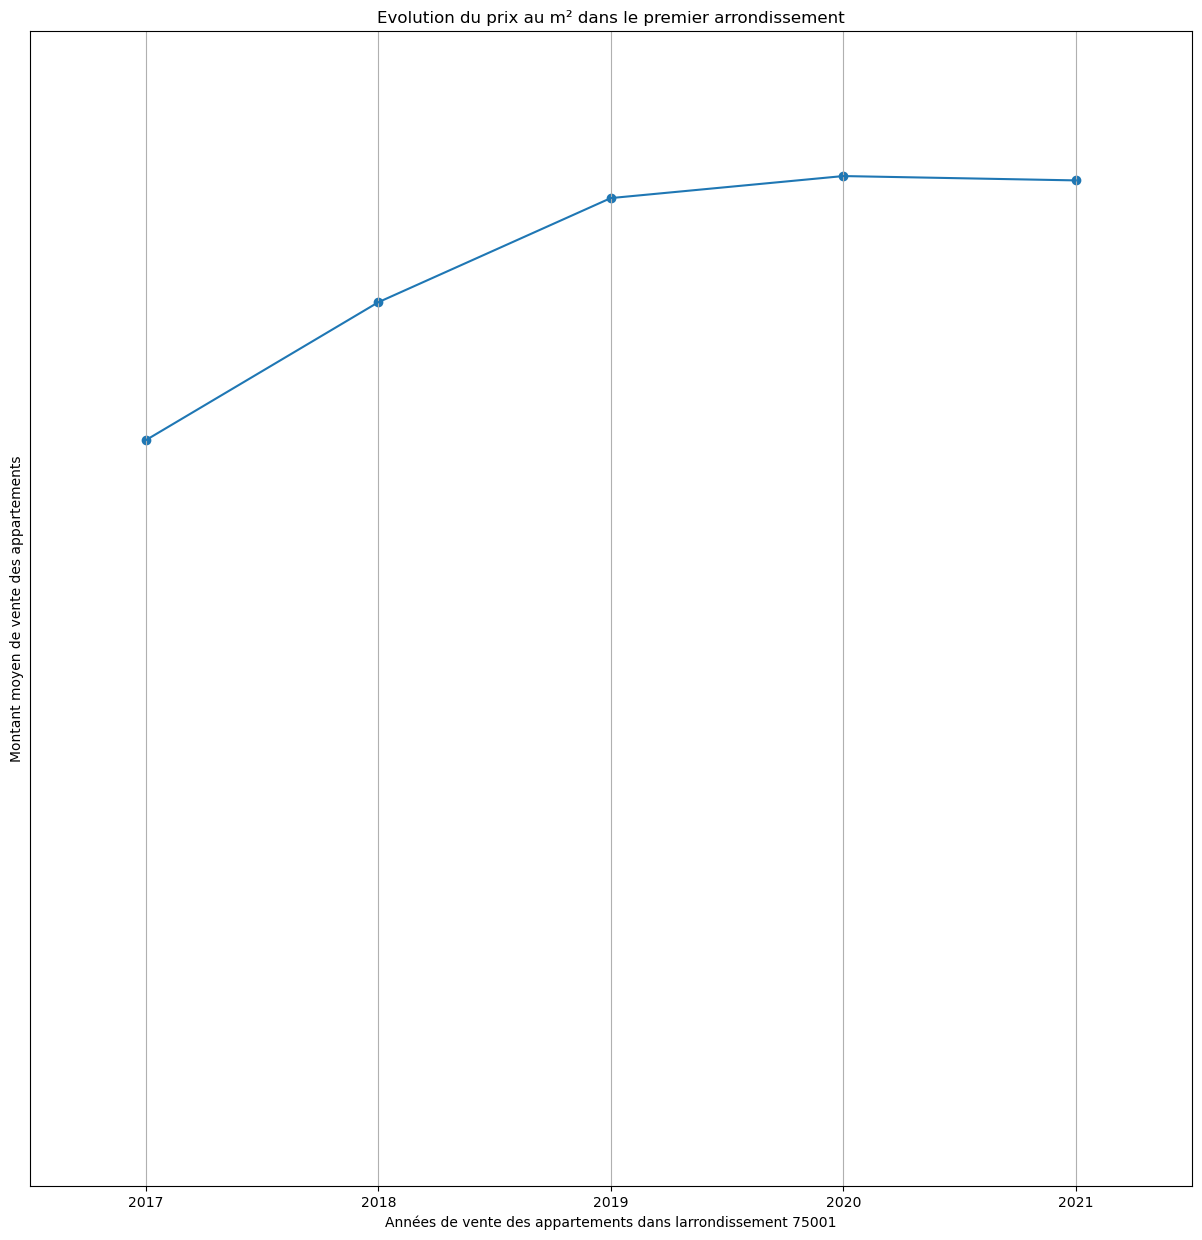

In [14]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement
plt.figure(figsize=(15,15))
plt.scatter(evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75001"]["annee"], evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75001"]["prix_m2"])
plt.plot(evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75001"]["annee"], evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75001"]["prix_m2"])
plt.plot(['2017','2018','2019','2020','2021'],color='red')
plt.xlabel('Années de vente des appartements dans larrondissement 75001')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.xlim(evolution_prix_arrond["annee"].min()-0.5,
         evolution_prix_arrond["annee"].max()+0.5)
plt.ylim(evolution_prix_arrond["prix_m2"].min()-500,
         evolution_prix_arrond["prix_m2"].max()+500)
plt.grid()
plt.title('Evolution du prix au m² dans le premier arrondissement')
plt.show()

Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

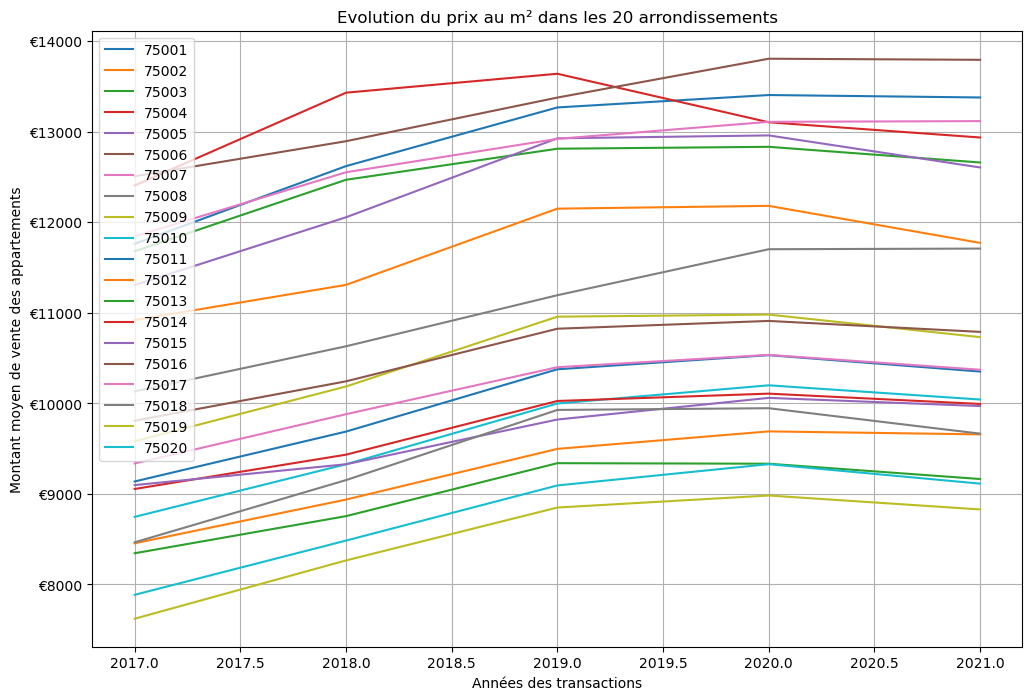

In [15]:
#On affiche l'évolution du prix au m² par arrondissement dans Paris
plt.figure(figsize=(12,8))
interval_historique=['2017','2018','2019','2020','2021']
#Insérer les lignes à tracer ci-dessous
for cp in evolution_prix_arrond["code_postal"].unique():
    subset = evolution_prix_arrond[evolution_prix_arrond["code_postal"] == cp]
    plt.plot(subset["annee"], subset["prix_m2"], label=cp)

plt.xlabel('Années des transactions')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans les 20 arrondissements')
plt.legend(loc='upper left')
plt.show()

On observe, comme pour l'ensemble de Paris, que les prix dans chaque arrondissement montent entre 2017 et 2020 et on a un léger repli en 2021 (parfois dès 2020)

### 7. Prix au metre carré par transaction dans un arrondissement

In [16]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé
sales_75006 = sales[sales["code_postal"] == "75006"].copy()
sales_75006["annee"] = sales_75006["date_mutation"].dt.year
print("Le nombre de transactions pour les appartements dans le 6e arrondissement est : " + str(len(sales_75006)))

Le nombre de transactions pour les appartements dans le 6e arrondissement est : 782


On constate que le nombre de transactions est significatif.

Affichons l'historique des transactions pour visualiser la dispersion des données :

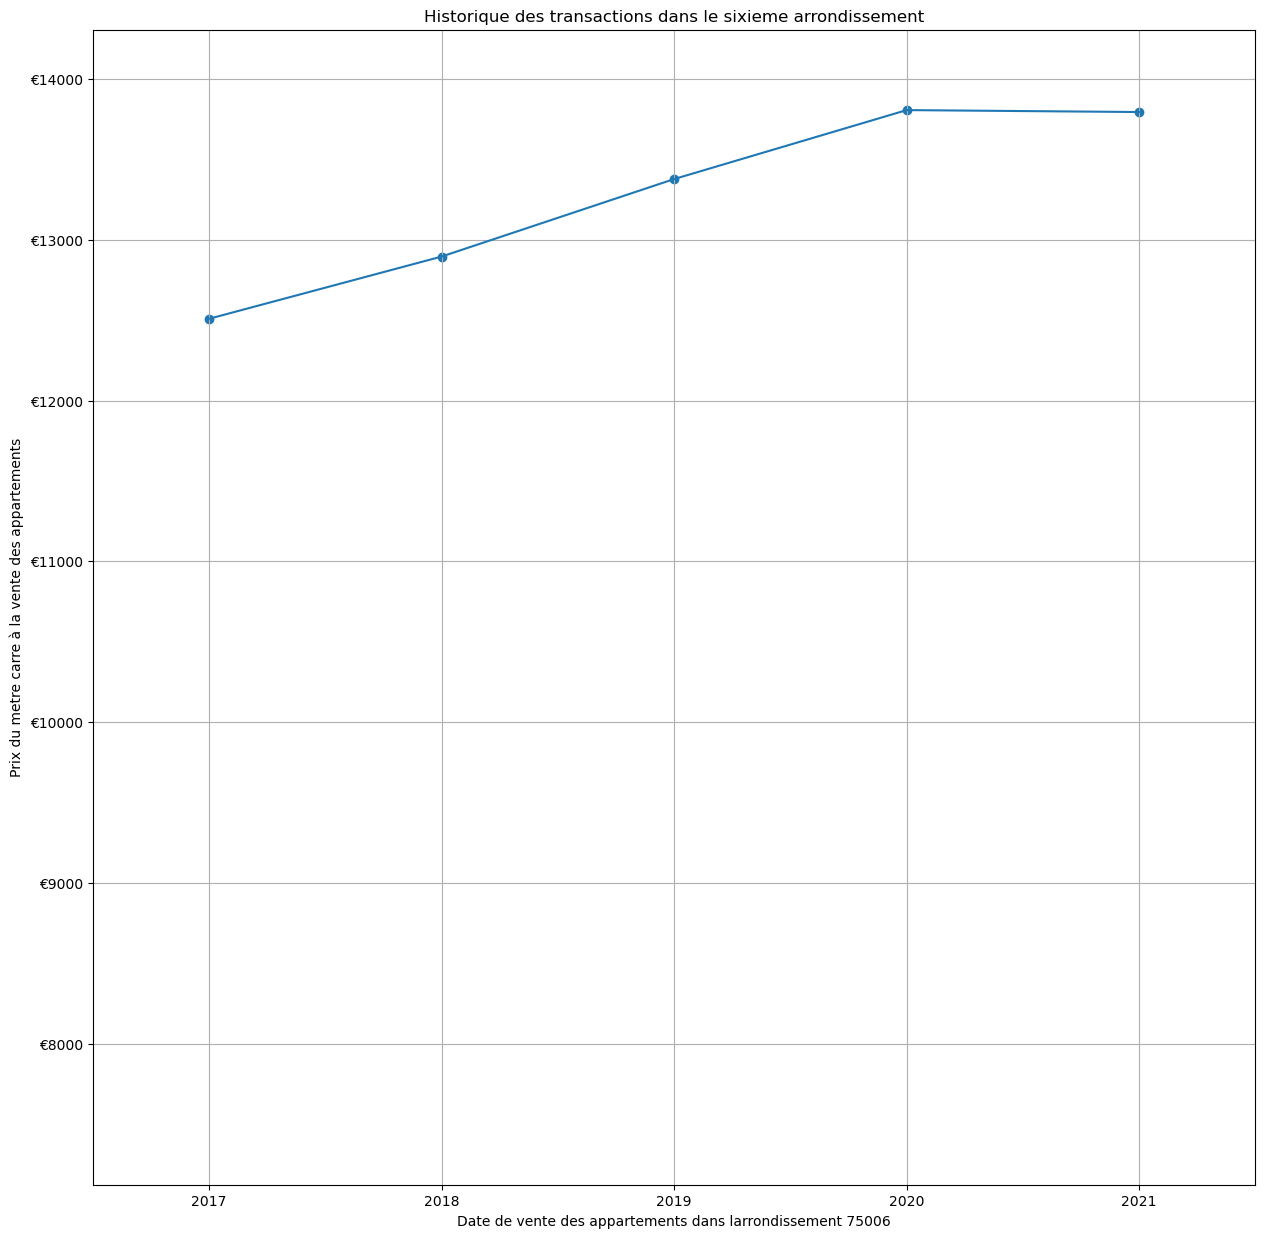

In [17]:
cp=75006
plt.figure(figsize=(15,15))
#Insérer ci-dessous le scatter plot
plt.scatter(evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75006"]["annee"], evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75006"]["prix_m2"])
plt.plot(evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75006"]["annee"], evolution_prix_arrond[evolution_prix_arrond["code_postal"] == "75006"]["prix_m2"])

plt.xlabel('Date de vente des appartements dans larrondissement 75006')
plt.ylabel('Prix du metre carre à la vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylim(0,1)
plt.xlim(evolution_prix_arrond["annee"].min()-0.5,
         evolution_prix_arrond["annee"].max()+0.5)
plt.ylim(evolution_prix_arrond["prix_m2"].min()-500,
         evolution_prix_arrond["prix_m2"].max()+500)
plt.grid(which='both')
plt.title('Historique des transactions dans le sixieme arrondissement')
plt.show()

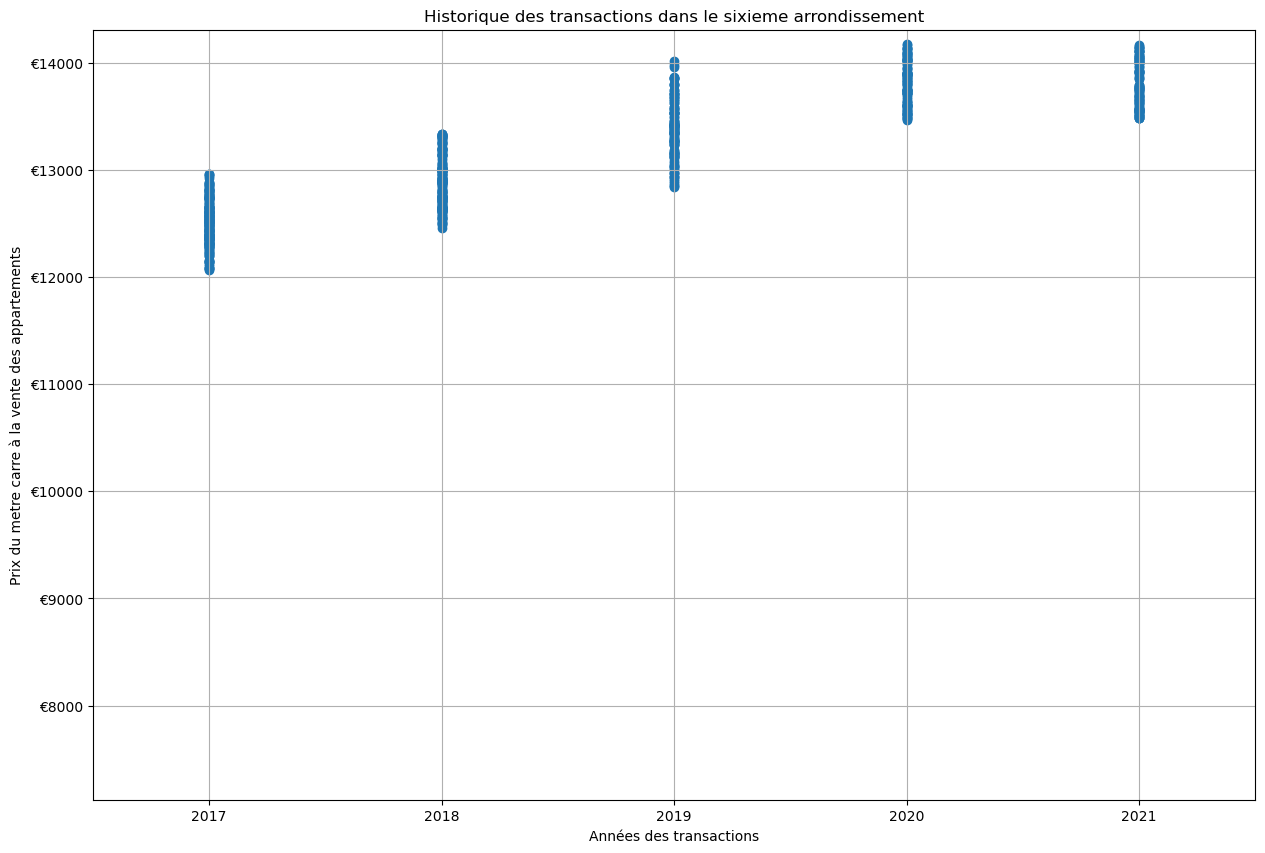

In [18]:
cp=75006
plt.figure(figsize=(15,10))
#Insérer ci-dessous le scatter plot
plt.scatter(sales_flats_price_arrond[sales_flats_price_arrond["code_postal"] == "75006"]["annee"], sales_flats_price_arrond[sales_flats_price_arrond["code_postal"] == "75006"]["prix_m2"])
#plt.plot(sales_flats_price_arrond[sales_flats_price_arrond["code_postal"] == "75006"]["annee"], sales_flats_price_arrond[sales_flats_price_arrond["code_postal"] == "75006"]["prix_m2"])

plt.xlabel('Années des transactions')
plt.ylabel('Prix du metre carre à la vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylim(0,1)
plt.xlim(evolution_prix_arrond["annee"].min()-0.5,
         evolution_prix_arrond["annee"].max()+0.5)
plt.ylim(evolution_prix_arrond["prix_m2"].min()-500,
         evolution_prix_arrond["prix_m2"].max()+500)
plt.grid(which='both')
plt.title('Historique des transactions dans le sixieme arrondissement')
plt.show()

On observe que les prix sont en moyenne plus élevés mais évoluent de manière semblables au reste de Paris. 

Pour nous rassurer sur la relation entre les données nous allons utiliser un test statistique de corrélation.

### 8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson 

Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [19]:
#On calcule la corrélation de Pearson
from scipy import stats

#Calcul du coefficient de corrélation de Pearson
corr_pearson, p_value_p = stats.pearsonr(sales_75006["annee"], sales_75006["prix_m2"])

correlations = pd.DataFrame({
    "Mesure": ["Pearson"],
    "Coef": [round(corr_pearson, 2)],
    "p-value" : [p_value_p]
})

correlations

,Mesure,Coef,p-value
0,Pearson,0.76,2.439478e-149


Le coefficient de corrélation de Pearson est de 0.76 avec une pvalue très proche de 0 de  donc nous pouvons confirmer la corrélation.

### 9. Vérification de la relation entre la valeur fonciere et la surface

In [20]:
#Calcul du coefficient de corrélation de Pearson
corr_pearson, p_value_p = stats.pearsonr(sales["valeur_fonciere"], sales["surface_reelle"])


correlations = pd.DataFrame({
    "Mesure": ["Pearson"],
    "Coef": [round(corr_pearson, 2)],
    "p-value" : [p_value_p]
})

correlations

,Mesure,Coef,p-value
0,Pearson,0.98,0.0


Le coefficient de corrélation est de 0.98 avec une pvalue de 0. La relation est donc confirmée.

Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

### 10. Analyse des locaux industriels, commerciaux et assimilés 

In [21]:
#On crée un dataset qui ne contient que les locaux commerciaux
sales_comm_price = sales[sales["type_local"] != "Appartement"][["date_mutation", "prix_m2"]].copy()

In [22]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année
sales_comm_price["annee"] = sales_comm_price["date_mutation"].dt.year

evolution_prix_comm = (
    sales_comm_price
    .groupby("annee")["prix_m2"]
    .mean()
    .round()
    .reset_index()
)

evolution_prix_comm

,annee,prix_m2
0,2017,10950.0
1,2018,11569.0
2,2019,11960.0
3,2020,11966.0
4,2021,12006.0


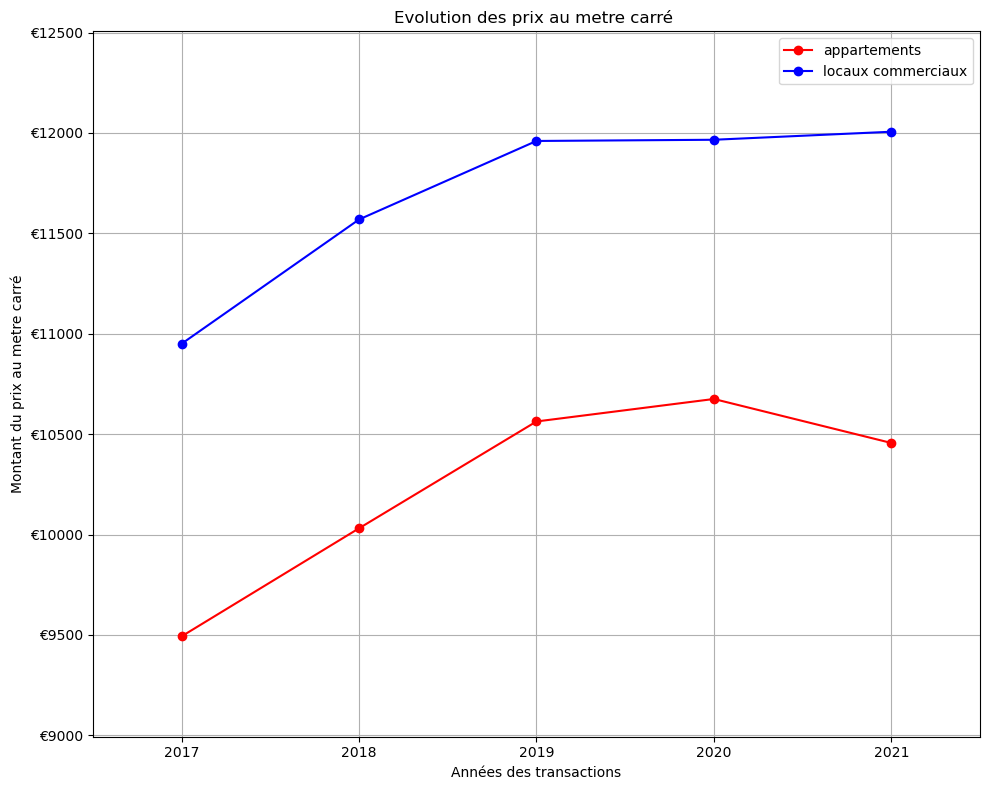

In [23]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
plt.figure(figsize=(10,8))
plt.plot(evolution_prix["annee"], evolution_prix["prix_m2"], marker="o", color="red", label="appartements")
plt.plot(evolution_prix_comm["annee"], evolution_prix_comm["prix_m2"], marker="o", color="blue", label="locaux commerciaux")
plt.xlabel('Années des transactions')
plt.ylabel('Montant du prix au metre carré')
plt.legend()
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.xlim(evolution_prix["annee"].min()-0.5,
         evolution_prix["annee"].max()+0.5)
plt.ylim(evolution_prix["prix_m2"].min()-500,
         evolution_prix_comm["prix_m2"].max()+500)
plt.grid()
plt.title('Evolution des prix au metre carré ')
plt.tight_layout()
plt.show()

Le prix au metre carré des locaux commerciaux est supérieur à celui des appartements. L'évolution est similaire, à l'exception de la baisse en 2021.

Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont : 
- la surface du bien immobilier,
- la date considérée, 
- la localisation (code_postal), 
- le type de bien.

# Milestone 2 - Entraînement de l'algorithme

Dans cette section nous allons maintenant entrainer un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [24]:
sales_ml = pd.get_dummies(
    sales,
    columns=["code_postal", "type_local"],
    drop_first=False
)
sales_ml["annee"] = sales_ml["date_mutation"].dt.year
y = sales_ml["valeur_fonciere"]

X = sales_ml.drop(columns=[
    "code_type_local",
    "valeur_fonciere",
    "date_mutation",
    "adresse_numero",
    "adresse_nom_voie",
    "nom_commune",
    "prix_m2"
])

print(X.shape, y.shape)
sales_ml.info()

(26196, 24) (26196,)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26196 entries, 0 to 26195
Data columns (total 31 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   date_mutation                                        26196 non-null  datetime64[ns]
 1   valeur_fonciere                                      26196 non-null  float64       
 2   adresse_numero                                       26196 non-null  int64         
 3   adresse_nom_voie                                     26196 non-null  object        
 4   nom_commune                                          26196 non-null  object        
 5   code_type_local                                      26196 non-null  int64         
 6   surface_reelle                                       26196 non-null  int64         
 7   prix_m2                                              26196 non-n

On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [25]:
# On sépare le jeu de données entre echantillons d'apprentissage et de test 
# La valeur y à trouver est la valeur foncière
from sklearn.model_selection import train_test_split

train = sales_ml[sales_ml["annee"] <= 2019]
test  = sales_ml[sales_ml["annee"] > 2019]

X_train = train[X.columns]
y_train = train["valeur_fonciere"]

X_test = test[X.columns]
y_test = test["valeur_fonciere"]

In [28]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("L'erreur moyenne vaut " + str(round(mape*100,1)) + "% et le coefficient de détermination " + str(round(r2,2)) + ".")

L'erreur moyenne vaut 2.2% et le coefficient de détermination 0.81.


Notre algorithme fait donc 2,2% d'erreur en moyenne sur la prédiction de la valeur foncière.

Mes conclusions sur ce résultat et comment j'aurais pu aller plus loin :
- Le taux d'erreur est très bon 
- Avec un split aléatoire, le modèle obtient un R² très élevé car il voit toutes les années dans l’entraînement. Ici en revanche, avec un split chronologique, on simule une situation réelle où l’on prédit le futur à partir du passé. Le score est donc plus faible mais l’évaluation est plus robuste et plus réaliste.
- Sécuriser l’évaluation : utiliser une cross-validation (K-fold) pour obtenir une performance moyenne plus robuste qu’un seul train_test_split.

# Milestone 3 - Prédiction définitive pour le client 

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez. 

In [29]:
#On importe les données dans un dataframe
portfolio = pd.read_excel("portefeuille_actifs.xlsx")

Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [30]:
#Conversion du dataframe en str
portfolio["code_postal"] = portfolio["code_postal"].astype(str)
portfolio["type_local"] = portfolio["type_local"].astype(str)

#On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles
portfolio_ml = pd.get_dummies(
    portfolio,
    columns=["code_postal", "type_local"],
    drop_first=False
)

portfolio_ml["surface_reelle"] = portfolio_ml["surface_reelle_bati"]
portfolio_ml["annee"] = 2022
portfolio_ml["annee"] = portfolio_ml["annee"].astype(int)

In [31]:
# Homogénéisation du portefeuille pour pouvoir faire les prédictions
portfolio_pred = portfolio_ml.drop(columns=[
    "code_commune",
    "surface_carrez",
    "surface_reelle_bati",
    "code_type_local",
    "nombre_pieces_principales",
    "adresse_numero",
    "adresse_nom_voie",
    "nom_commune",
    "longitude",
    "latitude"
])
portfolio_pred = portfolio_pred.reindex(columns=X_train.columns, fill_value=0)
portfolio_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 24 columns):
 #   Column                                               Non-Null Count  Dtype
---  ------                                               --------------  -----
 0   surface_reelle                                       275 non-null    int64
 1   code_postal_75001                                    275 non-null    bool 
 2   code_postal_75002                                    275 non-null    bool 
 3   code_postal_75003                                    275 non-null    bool 
 4   code_postal_75004                                    275 non-null    bool 
 5   code_postal_75005                                    275 non-null    bool 
 6   code_postal_75006                                    275 non-null    bool 
 7   code_postal_75007                                    275 non-null    bool 
 8   code_postal_75008                                    275 non-null    bool 
 9   code_posta

Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [32]:
# Vérification du nombre de colonnes
portfolio_pred.columns.equals(X_train.columns)

True

In [33]:
#On effectue la prédiction
predictions = model.predict(portfolio_pred.drop(columns=["valeur_predite"], errors="ignore"))
portfolio_pred["valeur_predite"] = predictions

#On vérifie les 10 premières valeurs
portfolio_pred[["surface_reelle", "annee", "valeur_predite"]].head(10)

,surface_reelle,annee,valeur_predite
0,25,2022,330797.562500
1,22,2022,279182.937500
2,65,2022,834069.875000
3,74,2022,824604.375000
4,22,2022,246627.000000
5,35,2022,392948.500000
6,24,2022,306903.875000
7,60,2022,599172.062500
8,11,2022,115227.890625
9,13,2022,129072.703125


Maintenant nous allons comparer la valorisation prédite pour les deux segments.

In [34]:
#Valorisation du portefeuille sur le segment des particuliers
valorisation_part = portfolio_pred.loc[
    portfolio_pred["type_local_Appartement"] == 1,
    "valeur_predite"
].sum()

nb_part = portfolio_pred["type_local_Appartement"].sum()
print('La valorisation du segment particulier est (en millions deuros): ' + str(f"{valorisation_part:,.0f}".replace(","," ")) + " € pour " + str(nb_part) + " logements.")

La valorisation du segment particulier est (en millions deuros): 65 264 832 € pour 154 logements.


In [35]:
#Valorisation du portefeuille sur le segment corporate
valorisation_corp = portfolio_pred.loc[
    portfolio_pred["type_local_Local industriel. commercial ou assimilé"] == 1,
    "valeur_predite"
].sum()

nb_corp = portfolio_pred["type_local_Local industriel. commercial ou assimilé"].sum()

print('La valorisation du segment corporate est (en millions deuros): ' + str(f"{valorisation_corp:,.0f}".replace(","," ")) + " € pour " + str(nb_corp) + " biens.")

La valorisation du segment corporate est (en millions deuros): 96 493 472 € pour 121 biens.


In [36]:
# Calcul des moyennes
print("La moyenne de valeur des appartements est de " + str(f"{valorisation_part/nb_part:,.0f}".replace(","," ") + " €."))
print("La moyenne de valeur des biens commerciaux est de " + str(f"{valorisation_corp/nb_corp:,.0f}".replace(","," ") + " €."))
diff = (valorisation_corp/nb_corp)/(valorisation_part/nb_part)-1
print("En moyenne, les biens commerciaux valent " + str(f"{diff:.0%}") + " de plus que les appartements.")

La moyenne de valeur des appartements est de 423 798 €.
La moyenne de valeur des biens commerciaux est de 797 467 €.
En moyenne, les biens commerciaux valent 88% de plus que les appartements.


Mes conclusions sur le segment avec la plus grande valorisation et sur les limites de cette estimation :
- La valorisation du portefeuille corporate est supérieure, malgré un nombre de biens inférieurs.
- La valeur moyenne est 77% supérieure pour les biens commerciaux.

# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

In [37]:
#On importe les données dans un dataframe


On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

In [38]:
sales["annee"] = sales["date_mutation"].dt.year
sales_2021 = sales[sales["annee"] == 2021].copy()
sales_2021_19e = sales_2021[sales_2021["code_postal"] == "75019"].copy()
X_kmeans = sales_2021_19e[["prix_m2"]].copy()

Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

In [39]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_kmeans)
sales_2021_19e["cluster"] = kmeans.labels_

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(


In [40]:
# On vérifie les données de la prédiction
sales_2021_19e.groupby("cluster")["prix_m2"].mean()

cluster
0    8828.586057
1    9737.619986
Name: prix_m2, dtype: float64

Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement. 

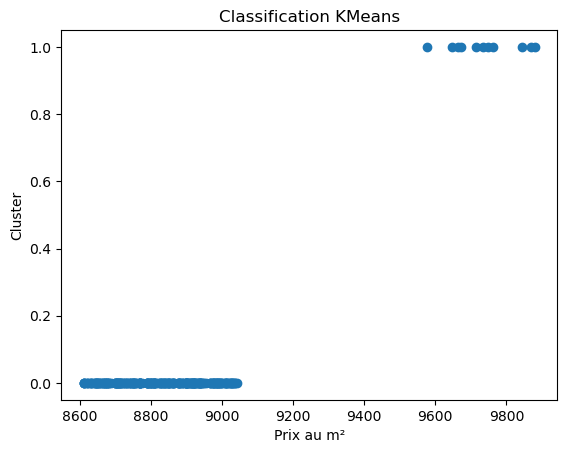

In [41]:
#On affiche les résultats
plt.scatter(sales_2021_19e["prix_m2"], sales_2021_19e["cluster"])
plt.xlabel("Prix au m²")
plt.ylabel("Cluster")
plt.title("Classification KMeans")
plt.show()

In [42]:
pd.crosstab(sales_2021_19e["type_local"], sales_2021_19e["cluster"])

cluster,0,1
type_local,,
Appartement,230,0
Local industriel. commercial ou assimilé,0,11


# Milestone 5 - Analyse et présentation des résultats

Mes conclusions sur l'analyse et les limites de l'exercice :
- Analyse puissante en choisissant les bons paramètres
- Raisonnement à effectuer pour chaque année
- Raisonnement à effectuer pour chaque arrondissement